
# 🏙️ Urban Noise Pollution Classifier — UrbanSound8K
### Dual-GPU (T4 x2) Deep Learning Pipeline for Real-Time Smart-City Noise Mapping

**Goal:** Train a fast, accurate audio classifier (>85% validation accuracy) on the
UrbanSound8K dataset that can later be compressed/quantized for deployment on
cheap, low-power IoT microphones.

**This notebook covers, end‑to‑end:**
1. Loading UrbanSound8K directly from the Kaggle input directory
2. One‑time, parallel CPU feature extraction (log‑mel spectrograms) cached to disk
   so the GPUs are never starved waiting on audio decoding during training
3. A leakage‑safe, official **fold‑based** train/validation split
4. A transfer‑learning CNN (ResNet18) adapted for spectrogram input
5. **True dual‑GPU training** using `nn.DataParallel` across both T4s, with
   mixed precision (AMP), Mixup, label smoothing and SpecAugment for
   regularization (the previous run overfit: 88.4% train vs 82.15% val)
6. **Early stopping** that restores the best epoch's weights automatically
7. Full evaluation: per‑class accuracy, classification report, confusion matrix
8. Saving the final best model (+ a TorchScript export for later edge deployment)

> **Run order:** Run all cells top-to-bottom on a Kaggle Notebook with
> **Accelerator = GPU T4 x2**, and the dataset
> `chrisfilo/urbansound8k` added as an input. No manual edits are required
> unless you want to tweak `CONFIG` below.


## 1. Environment Check & Reproducibility

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:

import os, random, warnings, json, time, math
warnings.filterwarnings("ignore")

import numpy as np
import torch

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_everything()

torch.backends.cudnn.benchmark = True   # speeds up convs since input size is fixed

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
NUM_GPUS = torch.cuda.device_count()
print("GPU count       :", NUM_GPUS)
for i in range(NUM_GPUS):
    print(f"  cuda:{i} -> {torch.cuda.get_device_name(i)}")

if NUM_GPUS < 2:
    print("\n⚠️  Less than 2 GPUs detected. The notebook will still run "
          "(falls back to single-GPU / CPU) but for the intended dual-T4 "
          "throughput make sure the Kaggle Accelerator is set to 'GPU T4 x2'.")


PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU count       : 2
  cuda:0 -> Tesla T4
  cuda:1 -> Tesla T4


## 2. Install / Import Libraries

In [3]:

# Kaggle images already ship torch, torchaudio, torchvision, librosa, sklearn.
# This just guards against a missing package without re-installing everything.
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["torchaudio", "librosa", "soundfile", "tqdm"]:
    ensure(pkg)

import pandas as pd
import librosa
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

print("All libraries imported successfully.")


All libraries imported successfully.


## 3. Config — paths & hyperparameters (edit here if needed)

In [4]:

CONFIG = {
    # ---- paths (Kaggle mounts the dataset read-only under /kaggle/input) ----
    "DATA_ROOT":   "/kaggle/input/datasets/chrisfilo/urbansound8k",       # contains fold1..fold10 + metadata
    "META_CSV":    "/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv",
    "AUDIO_DIR":   "/kaggle/input/datasets/chrisfilo/urbansound8k",        # audio is under <root>/foldN/
    "FEATURE_DIR": "/kaggle/working/features",          # cached log-mel spectrograms
    "MODEL_DIR":   "/kaggle/working/models",

    # ---- audio / feature extraction ----
    "SAMPLE_RATE": 22050,
    "DURATION":    4.0,        # seconds; UrbanSound8K clips are <=4s, we pad/trim to this
    "N_MELS":      128,
    "N_FFT":       1024,
    "HOP_LENGTH":  512,
    "TOP_DB":      80,

    # ---- training ----
    "VAL_FOLD":       10,      # official fold held out for validation (folds 1-9 = train)
    "BATCH_SIZE_PER_GPU": 64,  # effective batch size = this * NUM_GPUS
    "NUM_WORKERS":    4,
    "EPOCHS":         40,
    "LR":             3e-4,
    "WEIGHT_DECAY":   1e-4,
    "LABEL_SMOOTHING":0.1,
    "MIXUP_ALPHA":    0.2,
    "EARLY_STOP_PATIENCE": 8,
    "GRAD_CLIP":      5.0,
}

os.makedirs(CONFIG["FEATURE_DIR"], exist_ok=True)
os.makedirs(CONFIG["MODEL_DIR"], exist_ok=True)

NUM_GPUS = max(1, torch.cuda.device_count())
BATCH_SIZE = CONFIG["BATCH_SIZE_PER_GPU"] * NUM_GPUS
print(f"Effective batch size: {BATCH_SIZE}  ({CONFIG['BATCH_SIZE_PER_GPU']} x {NUM_GPUS} GPU(s))")


Effective batch size: 128  (64 x 2 GPU(s))


## 4. Load Metadata

Total clips: 8732


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing



Classes: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']


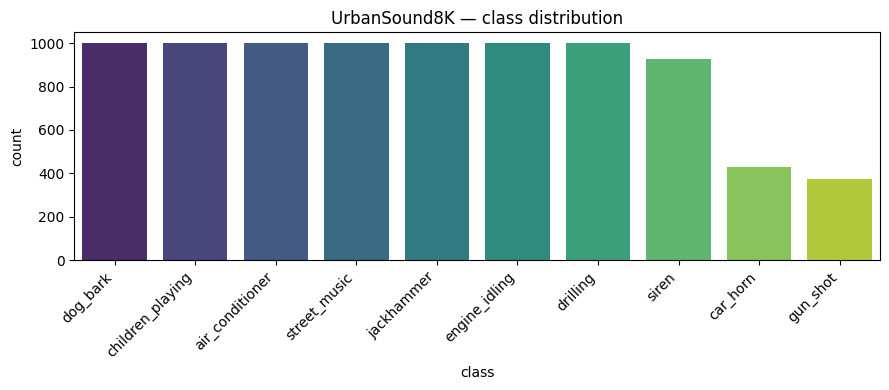


Clips per fold:
fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64


In [5]:

meta = pd.read_csv("/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv")
print("Total clips:", len(meta))
display(meta.head())

class_names = (meta[["classID", "class"]]
               .drop_duplicates()
               .sort_values("classID")["class"]
               .tolist())
NUM_CLASSES = len(class_names)
print("\nClasses:", class_names)

plt.figure(figsize=(9, 4))
sns.countplot(data=meta, x="class",
              order=meta["class"].value_counts().index, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("UrbanSound8K — class distribution")
plt.tight_layout()
plt.show()

print("\nClips per fold:")
print(meta["fold"].value_counts().sort_index())



## 5. Feature Extraction — precompute log-mel spectrograms (parallel, one-time)

Doing this **once**, in parallel across CPU cores, before training starts is what
keeps the two T4s fed during the actual training loop — decoding raw `.wav`
files with `librosa` on-the-fly every epoch is the #1 cause of GPU-starved,
CPU-bound training. Cached features are stored as `.npy` under
`/kaggle/working/features/<slice_file_name>.npy`.


In [6]:

def load_fixed_length_audio(path, sr, duration):
    """Load audio, force mono, resample, and pad/trim to a fixed length."""
    y, orig_sr = librosa.load(path, sr=sr, mono=True)
    target_len = int(sr * duration)
    if len(y) > target_len:
        y = y[:target_len]
    elif len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    return y

def extract_logmel(y, sr, n_mels, n_fft, hop_length, top_db):
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )
    logmel = librosa.power_to_db(mel, top_db=top_db)
    # normalize to roughly [0, 1] for stable training
    logmel = (logmel - logmel.min()) / (logmel.max() - logmel.min() + 1e-6)
    return logmel.astype(np.float32)

def process_one(args):
    slice_name, fold, cfg = args
    out_path = os.path.join(cfg["FEATURE_DIR"], slice_name.replace(".wav", ".npy"))
    if os.path.exists(out_path):
        return slice_name, True, None
    try:
        in_path = os.path.join(cfg["AUDIO_DIR"], f"fold{fold}", slice_name)
        y = load_fixed_length_audio(in_path, cfg["SAMPLE_RATE"], cfg["DURATION"])
        feat = extract_logmel(y, cfg["SAMPLE_RATE"], cfg["N_MELS"],
                               cfg["N_FFT"], cfg["HOP_LENGTH"], cfg["TOP_DB"])
        np.save(out_path, feat)
        return slice_name, True, None
    except Exception as e:
        return slice_name, False, str(e)

tasks = [(row.slice_file_name, row.fold, CONFIG) for row in meta.itertuples()]

failed = []
n_workers = max(1, mp.cpu_count() - 1)
print(f"Extracting log-mel features with {n_workers} parallel CPU workers "
      f"for {len(tasks)} clips (one-time cost)...")

with ProcessPoolExecutor(max_workers=n_workers) as ex:
    futures = [ex.submit(process_one, t) for t in tasks]
    for f in tqdm(as_completed(futures), total=len(futures)):
        name, ok, err = f.result()
        if not ok:
            failed.append((name, err))

print(f"\nDone. {len(tasks) - len(failed)}/{len(tasks)} succeeded.")
if failed:
    print(f"⚠️  {len(failed)} files failed to process (showing up to 5):")
    for name, err in failed[:5]:
        print(" -", name, "->", err)
    # Drop any rows whose features could not be extracted so training never crashes on them
    bad_names = {n for n, _ in failed}
    meta = meta[~meta["slice_file_name"].isin(bad_names)].reset_index(drop=True)


Extracting log-mel features with 3 parallel CPU workers for 8732 clips (one-time cost)...


  0%|          | 0/8732 [00:00<?, ?it/s]


Done. 8732/8732 succeeded.


## 6. Fold-based Train/Validation Split (leakage-safe)

In [7]:

# UrbanSound8K's own authors specify that folds must be respected — clips
# are pre-grouped by *source recording*, so a random shuffle-split would leak
# near-duplicate audio between train and val and inflate accuracy artificially.
train_df = meta[meta["fold"] != CONFIG["VAL_FOLD"]].reset_index(drop=True)
val_df   = meta[meta["fold"] == CONFIG["VAL_FOLD"]].reset_index(drop=True)

print(f"Train clips: {len(train_df)}  |  Val clips (fold {CONFIG['VAL_FOLD']}): {len(val_df)}")


Train clips: 7895  |  Val clips (fold 10): 837


## 7. Dataset, SpecAugment & Mixup

In [8]:

class UrbanSoundDataset(Dataset):
    def __init__(self, df, feature_dir, train=True):
        self.df = df.reset_index(drop=True)
        self.feature_dir = feature_dir
        self.train = train

    def __len__(self):
        return len(self.df)

    def _spec_augment(self, spec, n_freq_masks=2, n_time_masks=2,
                       freq_mask_pct=0.12, time_mask_pct=0.12):
        spec = spec.copy()
        n_mels, n_frames = spec.shape
        for _ in range(n_freq_masks):
            f = int(np.random.uniform(0, freq_mask_pct) * n_mels)
            f0 = np.random.randint(0, max(1, n_mels - f))
            spec[f0:f0 + f, :] = 0.0
        for _ in range(n_time_masks):
            t = int(np.random.uniform(0, time_mask_pct) * n_frames)
            t0 = np.random.randint(0, max(1, n_frames - t))
            spec[:, t0:t0 + t] = 0.0
        return spec

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname = row["slice_file_name"].replace(".wav", ".npy")
        feat = np.load(os.path.join(self.feature_dir, fname))  # (n_mels, n_frames)

        if self.train:
            feat = self._spec_augment(feat)

        # replicate to 3 channels so we can use ImageNet-pretrained CNN weights
        feat = np.stack([feat, feat, feat], axis=0)  # (3, n_mels, n_frames)
        x = torch.from_numpy(feat).float()
        y = int(row["classID"])
        return x, y

train_ds = UrbanSoundDataset(train_df, CONFIG["FEATURE_DIR"], train=True)
val_ds   = UrbanSoundDataset(val_df,   CONFIG["FEATURE_DIR"], train=False)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=CONFIG["NUM_WORKERS"], pin_memory=True,
    drop_last=True, persistent_workers=CONFIG["NUM_WORKERS"] > 0,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"], pin_memory=True,
    persistent_workers=CONFIG["NUM_WORKERS"] > 0,
)

xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape, "| labels shape:", yb.shape)

def mixup_batch(x, y, alpha, num_classes):
    """Standard mixup: blends pairs of inputs/labels for regularization."""
    if alpha <= 0:
        return x, F.one_hot(y, num_classes).float()
    lam = np.random.beta(alpha, alpha)
    perm = torch.randperm(x.size(0), device=x.device)
    x_mixed = lam * x + (1 - lam) * x[perm]
    y_onehot = F.one_hot(y, num_classes).float()
    y_mixed = lam * y_onehot + (1 - lam) * y_onehot[perm]
    return x_mixed, y_mixed


Batch shape: torch.Size([128, 3, 128, 173]) | labels shape: torch.Size([128])



## 8. Model — Transfer-Learning CNN (ResNet18 backbone)

A ResNet18 pretrained on ImageNet, fine-tuned on log-mel spectrograms
(treated as 3-channel "images"), reliably outperforms a small CNN trained
from scratch on a 6GB dataset like UrbanSound8K — it converges faster,
generalizes better (helps close the 88.4% train / 82.15% val gap from the
previous run) and is still small/fast enough to be pruned or quantized later
for IoT deployment.


In [9]:

def build_model(num_classes):
    model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    in_feats = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_feats, num_classes)
    )
    return model

model = build_model(NUM_CLASSES)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: ResNet18 | Trainable params: {n_params/1e6:.2f}M")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s]

Model: ResNet18 | Trainable params: 11.18M



## 9. Dual-GPU Setup

`nn.DataParallel` splits each batch evenly across both T4s in a single
process — the simplest way to guarantee balanced, crash-free multi-GPU use
inside a Kaggle notebook (no multiprocessing/DDP process-launch fragility).
Each GPU processes `BATCH_SIZE_PER_GPU` samples, gradients are averaged
automatically, and mixed precision (AMP) is layered on top for extra speed
and lower memory pressure on the T4s (16GB each).


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

if NUM_GPUS > 1:
    model = nn.DataParallel(model, device_ids=list(range(NUM_GPUS)))
    print(f"✅ Wrapped model in nn.DataParallel across GPUs: {list(range(NUM_GPUS))}")
else:
    print("Running on a single device:", device)

criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["LABEL_SMOOTHING"])
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["LR"],
                               weight_decay=CONFIG["WEIGHT_DECAY"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["EPOCHS"])
scaler = GradScaler()

✅ Wrapped model in nn.DataParallel across GPUs: [0, 1]


## 10. Early Stopping Utility

In [11]:
class EarlyStopping:
    """Stops training once val accuracy stops improving and keeps the best weights,
    so if the peak happens mid-run (e.g. epoch 9 of 40) we don't overtrain past it."""
    def __init__(self, patience=8, mode="max", min_delta=1e-4):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.best_state_dict = None
        self.stop = False

    def step(self, score, model):
        is_better = (
            self.best_score is None or
            (self.mode == "max" and score > self.best_score + self.min_delta) or
            (self.mode == "min" and score < self.best_score - self.min_delta)
        )
        if is_better:
            self.best_score = score
            self.counter = 0
            # store a CPU copy of weights (works whether or not wrapped in DataParallel)
            state = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
            self.best_state_dict = {k: v.detach().cpu().clone() for k, v in state.items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        return is_better


## 11. Train / Validate Loop

In [12]:

def run_epoch(model, loader, train, device, use_mixup=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        pbar = tqdm(loader, leave=False, desc="train" if train else "val")
        for x, y in pbar:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with autocast():
                if train and use_mixup and CONFIG["MIXUP_ALPHA"] > 0:
                    x_in, y_soft = mixup_batch(x, y, CONFIG["MIXUP_ALPHA"], NUM_CLASSES)
                    logits = model(x_in)
                    log_probs = F.log_softmax(logits, dim=1)
                    loss = -(y_soft * log_probs).sum(dim=1).mean()
                else:
                    logits = model(x)
                    loss = criterion(logits, y)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP"])
                scaler.step(optimizer)
                scaler.update()

            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            total_loss += loss.item() * y.size(0)
            all_preds.append(preds.detach().cpu())
            all_targets.append(y.detach().cpu())
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / total
    acc = correct / total
    preds_cat = torch.cat(all_preds).numpy()
    targets_cat = torch.cat(all_targets).numpy()
    return avg_loss, acc, preds_cat, targets_cat


## 12. Run Training (with early stopping + best-checkpoint saving)

In [13]:

early_stopper = EarlyStopping(patience=CONFIG["EARLY_STOP_PATIENCE"], mode="max")
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_ckpt_path = os.path.join(CONFIG["MODEL_DIR"], "best_model.pt")
start_time = time.time()

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    t0 = time.time()
    train_loss, train_acc, _, _ = run_epoch(model, train_loader, train=True, device=device)
    val_loss, val_acc, val_preds, val_targets = run_epoch(model, val_loader, train=False, device=device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    improved = early_stopper.step(val_acc, model)
    tag = "  ⭐ new best" if improved else ""
    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{CONFIG['EPOCHS']} | {dt:5.1f}s | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%{tag}")

    if early_stopper.stop:
        print(f"\n⏹️  Early stopping triggered at epoch {epoch} "
              f"(no improvement for {CONFIG['EARLY_STOP_PATIENCE']} epochs). "
              f"Best val acc: {early_stopper.best_score*100:.2f}%")
        break

total_time = time.time() - start_time
print(f"\n✅ Training complete in {total_time/60:.1f} min. "
      f"Best Validation Accuracy: {early_stopper.best_score*100:.2f}%")

# restore + save the best weights (not necessarily the last epoch's)
best_state = early_stopper.best_state_dict
raw_model = model.module if hasattr(model, "module") else model
raw_model.load_state_dict(best_state)
torch.save({
    "model_state_dict": best_state,
    "class_names": class_names,
    "config": CONFIG,
    "best_val_acc": early_stopper.best_score,
}, best_ckpt_path)
print("Saved best checkpoint to:", best_ckpt_path)


train:   0%|          | 0/61 [00:00<?, ?it/s]

val:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 01/40 |  37.7s | Train Loss: 1.2388 Acc: 38.09% | Val Loss: 1.0828 Acc: 78.49%  ⭐ new best


train:   0%|          | 0/61 [00:00<?, ?it/s]

val:   0%|          | 0/7 [00:00<?, ?it/s]

...

val:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 11/40 |  20.5s | Train Loss: 0.5255 Acc: 52.50% | Val Loss: 0.9198 Acc: 83.75%


train:   0%|          | 0/61 [00:00<?, ?it/s]

val:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 12/40 |  20.6s | Train Loss: 0.5333 Acc: 48.83% | Val Loss: 0.9703 Acc: 86.02%

⏹️  Early stopping triggered at epoch 12 (no improvement for 8 epochs). Best val acc: 87.81%

✅ Training complete in 4.4 min. Best Validation Accuracy: 87.81%
Saved best checkpoint to: /kaggle/working/models/best_model.pt


In [14]:
# Evaluate on the TRAINING fold with augmentation OFF, so it's directly
# comparable to val_acc (which also never sees augmentation).
train_eval_ds = UrbanSoundDataset(train_df, CONFIG["FEATURE_DIR"], train=False)
train_eval_loader = DataLoader(
    train_eval_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"], pin_memory=True,
)

clean_train_loss, clean_train_acc, _, _ = run_epoch(
    model, train_eval_loader, train=False, device=device
)
print(f"Clean (no-augmentation) train accuracy: {clean_train_acc*100:.2f}%")
print(f"Val accuracy (best epoch):              {early_stopper.best_score*100:.2f}%")
gap = clean_train_acc*100 - early_stopper.best_score*100
print(f"Gap: {gap:.2f} points "
      f"({'healthy — little to no overfitting' if gap < 8 else 'some overfitting, consider more regularization'})")

val:   0%|          | 0/62 [00:00<?, ?it/s]

Clean (no-augmentation) train accuracy: 95.86%
Val accuracy (best epoch):              87.81%
Gap: 8.04 points (some overfitting, consider more regularization)


## 13. Training Curves

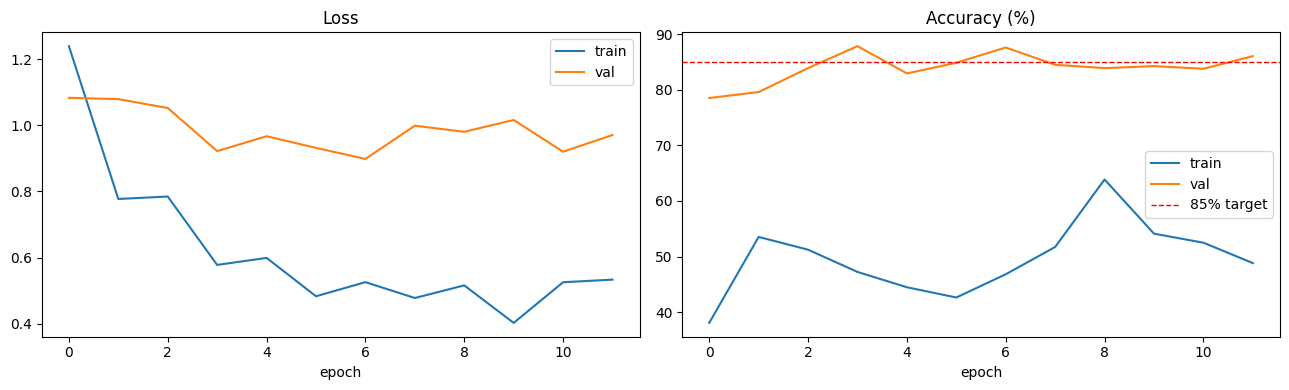

Saved training curves to: /kaggle/working/models/training_curves.png


In [15]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot([a*100 for a in history["train_acc"]], label="train")
axes[1].plot([a*100 for a in history["val_acc"]], label="val")
axes[1].axhline(85, color="red", linestyle="--", linewidth=1, label="85% target")
axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
curves_path = os.path.join(CONFIG["MODEL_DIR"], "training_curves.png")
plt.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved training curves to:", curves_path)


## 14. Final Evaluation on the Held-out Fold

val:   0%|          | 0/7 [00:00<?, ?it/s]

Final Validation Accuracy (best weights): 87.81%

Classification Report:

                  precision    recall  f1-score   support

 air_conditioner     0.7642    0.9400    0.8430       100
        car_horn     0.9062    0.8788    0.8923        33
children_playing     0.8036    0.9000    0.8491       100
        dog_bark     0.9494    0.7500    0.8380       100
        drilling     0.8854    0.8500    0.8673       100
   engine_idling     0.9452    0.7419    0.8313        93
        gun_shot     1.0000    1.0000    1.0000        32
      jackhammer     0.8624    0.9792    0.9171        96
           siren     0.9733    0.8795    0.9241        83
    street_music     0.8868    0.9400    0.9126       100

        accuracy                         0.8781       837
       macro avg     0.8977    0.8859    0.8875       837
    weighted avg     0.8869    0.8781    0.8775       837

Saved classification report to: /kaggle/working/models/classification_report.txt
Saved per-clip validation pred

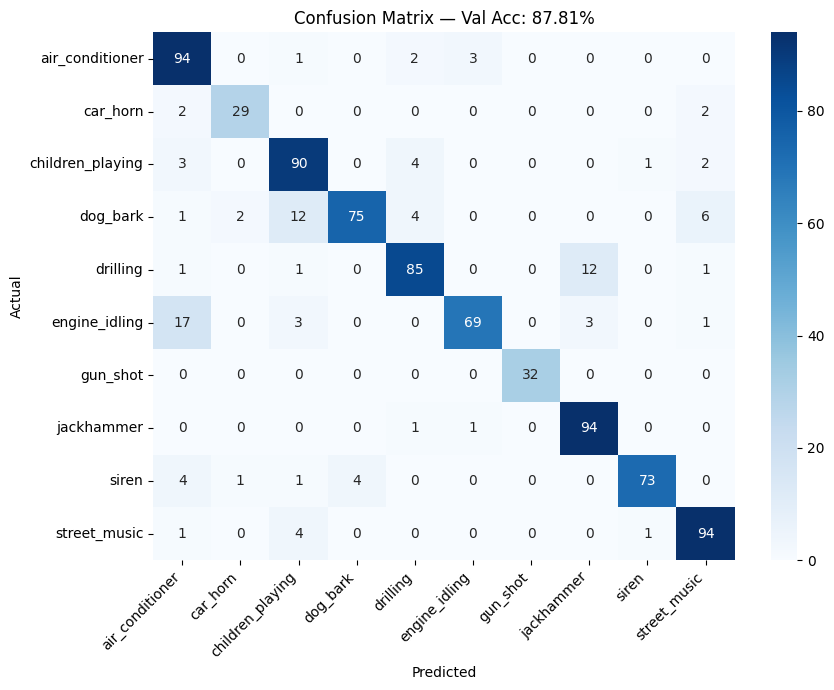

Saved confusion matrix to: /kaggle/working/models/confusion_matrix.png

🎯 Target reached: 87.81% >= 85%


In [16]:

final_loss, final_acc, final_preds, final_targets = run_epoch(
    model, val_loader, train=False, device=device
)
print(f"Final Validation Accuracy (best weights): {final_acc*100:.2f}%")

report_str = classification_report(final_targets, final_preds, target_names=class_names, digits=4)
print("\nClassification Report:\n")
print(report_str)

# save the classification (testing) report as a text file
report_path = os.path.join(CONFIG["MODEL_DIR"], "classification_report.txt")
with open(report_path, "w") as f:
    f.write(f"Final Validation Accuracy: {final_acc*100:.2f}%\n\n")
    f.write(report_str)
print("Saved classification report to:", report_path)

# save raw per-clip predictions vs ground truth (testing results)
results_df = pd.DataFrame({
    "slice_file_name": val_df["slice_file_name"].values,
    "true_classID": final_targets,
    "true_class": [class_names[i] for i in final_targets],
    "pred_classID": final_preds,
    "pred_class": [class_names[i] for i in final_preds],
    "correct": final_targets == final_preds,
})
results_csv_path = os.path.join(CONFIG["MODEL_DIR"], "val_predictions.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved per-clip validation predictions to:", results_csv_path)

cm = confusion_matrix(final_targets, final_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Val Acc: {final_acc*100:.2f}%")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
cm_path = os.path.join(CONFIG["MODEL_DIR"], "confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved confusion matrix to:", cm_path)

if final_acc >= 0.85:
    print(f"\n🎯 Target reached: {final_acc*100:.2f}% >= 85%")
else:
    print(f"\nℹ️  Current run: {final_acc*100:.2f}%. If below 85%, try: more epochs "
          f"(raise CONFIG['EPOCHS']), a bigger backbone (resnet34), or lowering "
          f"MIXUP_ALPHA slightly (e.g. 0.1) for less aggressive regularization.")


## 14.5 Quick manual inference check

In [17]:
def predict_audio_file(path, model, device):
    """Runs the EXACT SAME preprocessing used during training (Section 5's
    librosa-based load_fixed_length_audio + extract_logmel) on ONE audio file.
    No augmentation, eval mode only."""
    y = load_fixed_length_audio(path, CONFIG["SAMPLE_RATE"], CONFIG["DURATION"])
    arr = extract_logmel(y, CONFIG["SAMPLE_RATE"], CONFIG["N_MELS"],
                          CONFIG["N_FFT"], CONFIG["HOP_LENGTH"], CONFIG["TOP_DB"])
    x = torch.from_numpy(arr).float()
    x = x.unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).to(device)  # (1, 3, n_mels, n_frames)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()

    top3_idx = probs.argsort()[::-1][:3]
    top3 = [(class_names[i], float(probs[i])) for i in top3_idx]
    return class_names[top3_idx[0]], float(probs[top3_idx[0]]), top3

# spot-check on a handful of random clips from the held-out validation fold
sample_rows = val_df.sample(n=min(8, len(val_df)), random_state=1)
n_correct = 0
for _, row in sample_rows.iterrows():
    path = os.path.join(CONFIG["AUDIO_DIR"], f"fold{row.fold}", row.slice_file_name)
    pred_class, conf, top3 = predict_audio_file(path, raw_model, device)
    true_class = row["class"]
    is_correct = pred_class == true_class
    n_correct += int(is_correct)
    mark = "✅" if is_correct else "❌"
    print(f"{mark} {row.slice_file_name:22s} | true: {true_class:16s} | "
          f"pred: {pred_class:16s} ({conf*100:5.1f}%) | "
          f"top3: {[f'{c}:{p*100:.0f}%' for c, p in top3]}")

print(f"\n{n_correct}/{len(sample_rows)} correct on this random spot check "
      f"(a small sample — trust the full classification report above for the real number).")

✅ 99192-4-0-33.wav       | true: drilling         | pred: drilling         ( 99.2%) | top3: ['drilling:99%', 'dog_bark:0%', 'jackhammer:0%']
✅ 162134-7-14-2.wav      | true: jackhammer       | pred: jackhammer       ( 98.5%) | top3: ['jackhammer:99%', 'drilling:0%', 'children_playing:0%']
✅ 162134-7-11-3.wav      | true: jackhammer       | pred: jackhammer       ( 94.9%) | top3: ['jackhammer:95%', 'drilling:2%', 'air_conditioner:1%']
✅ 97756-3-0-0.wav        | true: dog_bark         | pred: dog_bark         ( 47.4%) | top3: ['dog_bark:47%', 'car_horn:17%', 'jackhammer:12%']
✅ 159742-8-0-12.wav      | true: siren            | pred: siren            ( 57.0%) | top3: ['siren:57%', 'engine_idling:18%', 'drilling:8%']
✅ 178402-1-0-0.wav       | true: car_horn         | pred: car_horn         ( 98.5%) | top3: ['car_horn:98%', 'dog_bark:0%', 'drilling:0%']
✅ 188813-7-10-0.wav      | true: jackhammer       | pred: jackhammer       ( 98.6%) | top3: ['jackhammer:99%', 'drilling:1%', 'car_horn:0%


## 15. Save Final Artifacts (for the later UI / deployment stage)

Saves:
- `best_model.pt` — full checkpoint (weights + config + class names), already written above
- `model_scripted.pt` — a TorchScript export (portable, no Python class needed to load it)
- `training_history.json` — loss/accuracy curves for your records


In [18]:

raw_model.eval()
example_input = torch.randn(1, 3, CONFIG["N_MELS"],
                             int(np.ceil(CONFIG["SAMPLE_RATE"] * CONFIG["DURATION"] / CONFIG["HOP_LENGTH"])) + 1).to(device)
try:
    scripted = torch.jit.trace(raw_model, example_input)
    scripted_path = os.path.join(CONFIG["MODEL_DIR"], "model_scripted.pt")
    scripted.save(scripted_path)
    print("Saved TorchScript model to:", scripted_path)
except Exception as e:
    print("TorchScript export skipped (non-fatal):", e)

with open(os.path.join(CONFIG["MODEL_DIR"], "training_history.json"), "w") as f:
    json.dump(history, f, indent=2)

print("\nAll artifacts saved under:", CONFIG["MODEL_DIR"])
print(os.listdir(CONFIG["MODEL_DIR"]))
print(f"\nBest Validation Accuracy: {early_stopper.best_score*100:.2f}%")
print("Notebook run complete — save this as a Kaggle Version to persist the outputs.")


Saved TorchScript model to: /kaggle/working/models/model_scripted.pt

All artifacts saved under: /kaggle/working/models
['classification_report.txt', 'training_curves.png', 'model_scripted.pt', 'val_predictions.csv', 'training_history.json', 'best_model.pt', 'confusion_matrix.png']

Best Validation Accuracy: 87.81%
Notebook run complete — save this as a Kaggle Version to persist the outputs.


## 16. Zip Everything into One Downloadable File (Kaggle Output)

Bundles the best model checkpoint, the TorchScript export, and every
training/testing result (accuracy curves, classification report, confusion
matrix, per-clip predictions CSV) into a single `.zip` under
`/kaggle/working/`. Anything in `/kaggle/working` is automatically attached
to the notebook's **Output** tab once you click **Save Version** — the zip
just makes it one clean file to grab instead of browsing individual files.


In [19]:

import shutil, zipfile

ZIP_NAME = "urban_sound_classifier_results"
zip_base_path = os.path.join("/kaggle/working", ZIP_NAME)   # shutil adds .zip
zip_final_path = zip_base_path + ".zip"

expected_files = [
    "best_model.pt",           # best checkpoint: weights + config + class names
    "model_scripted.pt",       # TorchScript export, for deployment later
    "training_history.json",   # per-epoch train/val loss & accuracy
    "training_curves.png",     # loss/accuracy plot
    "classification_report.txt",  # per-class precision/recall/F1 (testing results)
    "confusion_matrix.png",    # confusion matrix heatmap
    "val_predictions.csv",     # per-clip predicted vs true label (testing results)
]

missing = [f for f in expected_files
           if not os.path.exists(os.path.join(CONFIG["MODEL_DIR"], f))]
if missing:
    print("⚠️  These expected files are missing and will be skipped in the zip:")
    for m in missing:
        print("   -", m)

if os.path.exists(zip_final_path):
    os.remove(zip_final_path)

with zipfile.ZipFile(zip_final_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in expected_files:
        fpath = os.path.join(CONFIG["MODEL_DIR"], fname)
        if os.path.exists(fpath):
            zf.write(fpath, arcname=fname)

zip_size_mb = os.path.getsize(zip_final_path) / (1024 * 1024)
print(f"✅ Created {zip_final_path}  ({zip_size_mb:.2f} MB)")
print("\nContents:")
with zipfile.ZipFile(zip_final_path, "r") as zf:
    for info in zf.infolist():
        print(f"  - {info.filename}  ({info.file_size/1024:.1f} KB)")

# Optional: convenience download link when running interactively on Kaggle
try:
    from IPython.display import FileLink, display
    display(FileLink(zip_final_path))
except Exception as e:
    print("FileLink display skipped:", e)

print(f"\n📦 '{ZIP_NAME}.zip' will appear in the notebook's Output tab "
      f"after you click 'Save Version' (Save & Run All).")


✅ Created /kaggle/working/urban_sound_classifier_results.zip  (79.52 MB)

Contents:
  - best_model.pt  (43752.9 KB)
  - model_scripted.pt  (43874.7 KB)
  - training_history.json  (1.2 KB)
  - training_curves.png  (79.5 KB)
  - classification_report.txt  (0.8 KB)
  - confusion_matrix.png  (103.9 KB)
  - val_predictions.csv  (40.9 KB)


/kaggle/working/urban_sound_classifier_results.zip


📦 'urban_sound_classifier_results.zip' will appear in the notebook's Output tab after you click 'Save Version' (Save & Run All).


In [20]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import librosa
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------------------------------------------------
# 1) Load the checkpoint — it already contains CONFIG, class_names, weights
# ---------------------------------------------------------------------
CKPT_PATH = "/kaggle/working/models/best_model.pt"   # adjust if testing elsewhere

checkpoint = torch.load(CKPT_PATH, map_location="cpu")
CONFIG = checkpoint["config"]
class_names = checkpoint["class_names"]
NUM_CLASSES = len(class_names)
print(f"Loaded checkpoint | best val acc during training: {checkpoint['best_val_acc']*100:.2f}%")
print("Classes:", class_names)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------
# 2) Rebuild the exact model architecture, then load the saved weights
# ---------------------------------------------------------------------
def build_model(num_classes):
    model = torchvision.models.resnet18(weights=None)   # weights=None: we're loading our own
    in_feats = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_feats, num_classes))
    return model

model = build_model(NUM_CLASSES)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()
print("Model loaded and ready for inference.")

# ---------------------------------------------------------------------
# 3) SAME preprocessing used during training (librosa-based) — do not
#    swap this for torchaudio or any other library, or predictions will
#    silently degrade (see earlier note on mel-scale convention mismatch).
# ---------------------------------------------------------------------
def load_fixed_length_audio(path, sr, duration):
    y, _ = librosa.load(path, sr=sr, mono=True)
    target_len = int(sr * duration)
    if len(y) > target_len:
        y = y[:target_len]
    elif len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    return y

def extract_logmel(y, sr, n_mels, n_fft, hop_length, top_db):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    logmel = librosa.power_to_db(mel, top_db=top_db)
    logmel = (logmel - logmel.min()) / (logmel.max() - logmel.min() + 1e-6)
    return logmel.astype(np.float32)

def predict_audio_file(path, top_k=3):
    """Returns (predicted_class, confidence, top_k_list) for one audio file."""
    y = load_fixed_length_audio(path, CONFIG["SAMPLE_RATE"], CONFIG["DURATION"])
    arr = extract_logmel(y, CONFIG["SAMPLE_RATE"], CONFIG["N_MELS"],
                          CONFIG["N_FFT"], CONFIG["HOP_LENGTH"], CONFIG["TOP_DB"])
    x = torch.from_numpy(arr).float()
    x = x.unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).to(device)   # (1, 3, n_mels, n_frames)

    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()

    top_idx = probs.argsort()[::-1][:top_k]
    top_list = [(class_names[i], float(probs[i])) for i in top_idx]
    return class_names[top_idx[0]], float(probs[top_idx[0]]), top_list


# =======================================================================
# OPTION B — Test on N random real clips from the official held-out fold
# =======================================================================
META_CSV = CONFIG["META_CSV"]
meta = pd.read_csv(META_CSV)
test_df = meta[meta["fold"] == CONFIG["VAL_FOLD"]].reset_index(drop=True)

N_SAMPLES = 10
sample_rows = test_df.sample(n=min(N_SAMPLES, len(test_df)), random_state=1)

print(f"\n--- Spot check on {len(sample_rows)} random clips from fold {CONFIG['VAL_FOLD']} ---")
n_correct = 0
for _, row in sample_rows.iterrows():
    path = os.path.join(CONFIG["AUDIO_DIR"], f"fold{row.fold}", row.slice_file_name)
    pred, conf, top3 = predict_audio_file(path)
    true = row["class"]
    ok = pred == true
    n_correct += int(ok)
    mark = "✅" if ok else "❌"
    print(f"{mark} {row.slice_file_name:22s} | true: {true:16s} | pred: {pred:16s} ({conf*100:5.1f}%)")
print(f"{n_correct}/{len(sample_rows)} correct on this spot check.")


# =======================================================================
# OPTION C — Full aggregate test on the ENTIRE held-out fold (real numbers)
# =======================================================================
print(f"\n--- Full evaluation on all {len(test_df)} clips in fold {CONFIG['VAL_FOLD']} ---")
all_preds, all_targets = [], []
for _, row in test_df.iterrows():
    path = os.path.join(CONFIG["AUDIO_DIR"], f"fold{row.fold}", row.slice_file_name)
    pred, conf, _ = predict_audio_file(path)
    all_preds.append(class_names.index(pred))
    all_targets.append(int(row["classID"]))

acc = np.mean(np.array(all_preds) == np.array(all_targets))
print(f"Full fold-{CONFIG['VAL_FOLD']} accuracy: {acc*100:.2f}%\n")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))
print(confusion_matrix(all_targets, all_preds))

Loaded checkpoint | best val acc during training: 87.81%
Classes: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']
Model loaded and ready for inference.

--- Spot check on 10 random clips from fold 10 ---
✅ 99192-4-0-33.wav       | true: drilling         | pred: drilling         ( 99.2%)
✅ 162134-7-14-2.wav      | true: jackhammer       | pred: jackhammer       ( 98.5%)
✅ 162134-7-11-3.wav      | true: jackhammer       | pred: jackhammer       ( 94.9%)
✅ 97756-3-0-0.wav        | true: dog_bark         | pred: dog_bark         ( 47.4%)
✅ 159742-8-0-12.wav      | true: siren            | pred: siren            ( 57.0%)
✅ 178402-1-0-0.wav       | true: car_horn         | pred: car_horn         ( 98.5%)
✅ 188813-7-10-0.wav      | true: jackhammer       | pred: jackhammer       ( 98.6%)
✅ 188813-7-10-1.wav      | true: jackhammer       | pred: jackhammer       ( 97.6%)
✅ 100795-3-1-2.wav       | t